# LeetCode #107: Binary Tree Level Order Traversal II

https://leetcode.com/problems/binary-tree-level-order-traversal-ii/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| DFS with Level | O(n) | O(n) | Collect with DFS, reverse at end |
| BFS + LinkedList Prepend | O(n) | O(n) | AddFirst each level avoids final reverse |
| **BFS + Reverse ★** | **O(n)** | **O(n)** | Standard BFS then Reverse() — simplest |

---

## Understanding the Methods

### Brute Force (DFS)
DFS with level index. Collect in forward order. Reverse the final list. O(n) extra for reversal.

### BFS + Reverse (Optimal ★)
Identical to #102 BFS. After collecting all levels top-to-bottom, call Reverse() on the result list. O(n) reversal once — cleaner than maintaining a separate structure.

## Constraints
- Number of nodes: [0, 2000]
- Node values: [-1000, 1000]

## Solutions

### C#

In [ ]:
public class Solution {
    public IList<IList<int>> LevelOrderBottom(TreeNode root) {
        var result = new List<IList<int>>();
        if (root == null) return result;
        var queue = new Queue<TreeNode>();
        queue.Enqueue(root);
        while (queue.Count > 0) {
            int size  = queue.Count;
            var level = new List<int>();
            for (int i = 0; i < size; i++) {
                var node = queue.Dequeue();
                level.Add(node.val);
                if (node.left  != null) queue.Enqueue(node.left);
                if (node.right != null) queue.Enqueue(node.right);
            }
            result.Add(level);
        }
        result.Reverse();
        return result;
    }
}

### Python

In [ ]:
from collections import deque

class Solution:
    def levelOrderBottom(self, root) -> list[list[int]]:
        if not root: return []
        result, queue = [], deque([root])
        while queue:
            level = []
            for _ in range(len(queue)):
                node = queue.popleft()
                level.append(node.val)
                if node.left:  queue.append(node.left)
                if node.right: queue.append(node.right)
            result.append(level)
        return result[::-1]

### Go

In [ ]:
func levelOrderBottom(root *TreeNode) [][]int {
    if root == nil { return nil }
    result := [][]int{}
    queue  := []*TreeNode{root}
    for len(queue) > 0 {
        size  := len(queue)
        level := make([]int, 0, size)
        for i := 0; i < size; i++ {
            node  := queue[0]; queue = queue[1:]
            level  = append(level, node.Val)
            if node.Left  != nil { queue = append(queue, node.Left) }
            if node.Right != nil { queue = append(queue, node.Right) }
        }
        result = append(result, level)
    }
    // reverse
    for i, j := 0, len(result)-1; i < j; i, j = i+1, j-1 {
        result[i], result[j] = result[j], result[i]
    }
    return result
}

### Rust

In [ ]:
use std::rc::Rc;
use std::cell::RefCell;
use std::collections::VecDeque;

impl Solution {
    pub fn level_order_bottom(root: Option<Rc<RefCell<TreeNode>>>) -> Vec<Vec<i32>> {
        let mut result = vec![];
        let Some(r) = root else { return result; };
        let mut queue = VecDeque::from([r]);
        while !queue.is_empty() {
            let size = queue.len();
            let mut level = Vec::with_capacity(size);
            for _ in 0..size {
                let node = queue.pop_front().unwrap();
                level.push(node.borrow().val);
                if let Some(l) = node.borrow().left.clone()  { queue.push_back(l); }
                if let Some(r) = node.borrow().right.clone() { queue.push_back(r); }
            }
            result.push(level);
        }
        result.reverse();
        result
    }
}

## Example Scenarios

### 1. Common Case — Classic 3-Level Tree
**Input:** `root = [3, 9, 20, null, null, 15, 7]`

Standard BFS collects top-to-bottom: [[3], [9,20], [15,7]]. Reverse the list to get bottom-to-top: [[15,7], [9,20], [3]]. Within each level, node order (left-to-right) is preserved.

*Why tricky:* Baseline. Same BFS as #102, plus one $O(L)$ reverse. Confirms that intra-level ordering is unaffected by the level-list reversal.

$T(n) = O(n) + O(L)$ where $L = $ number of levels

**Output:** `[[15, 7], [9, 20], [3]]`

### 2. Slightly Complex — 4-Level Unbalanced Tree
**Input:** `root = [1, 2, 3, 4, 5, null, null, 8]`

BFS: L0=[1], L1=[2,3], L2=[4,5], L3=[8]. Reversed: [[8], [4,5], [2,3], [1]]. Node 3 has no children — level 2 only has nodes from node 2. Level 3 has a single node.

*Why tricky:* Unbalanced levels with different sizes (1, 2, 2, 1). The reversal handles uneven level sizes correctly. The last level has only 1 node despite level 2 having 2.

$|L_0| = 1, |L_1| = 2, |L_2| = 2, |L_3| = 1$ — non-uniform widths

**Output:** `[[8], [4, 5], [2, 3], [1]]`

### 3. Edge Case: Time Factor — Right-Skewed Chain (2000 Nodes)
**Input:** `root = 2000-node right-only chain, values 1..2000` (max constraint)

BFS produces 2000 single-element levels. Reverse swaps 1000 pairs. Total: $O(n) + O(n) = O(n)$. Match at the very end forces full scan.

*Why tricky:* Max $n = 2000$ with 2000 levels. Worst case for both BFS iterations and reversal count. The output list has 2000 sub-lists, each of size 1.

$T = O(n) + O(n/2) \text{ swaps} = O(2000)$

**Output:** `[[2000], [1999], ..., [1]]`

### 4. Edge Case: Space Factor — Perfect Tree (1023 Nodes, Depth 10)
**Input:** `root = perfect binary tree, 1023 nodes`

Queue peaks at 512 (last level). Output stores all 1023 values across 10 levels. Reverse is $O(10)$ — trivial. Space dominated by queue and output at $O(n)$.

*Why tricky:* Peak queue = $n/2 = 512$. Reverse = $O(\log n)$ swaps of level pointers (negligible). Space stress comes from queue + output, not reversal. Contrast with Ex 3 where reverse does $O(n)$ swaps.

$\max(|Q|) = 512$, reverse cost $= O(10)$

**Output:** `[[512 nodes], ..., [2 nodes], [1 node]]`

### 5. Almost-Impossible but Plausible — Single Node at Boundary Value
**Input:** `root = [-1000]`

BFS: one iteration, result = [[-1000]]. Reverse of a 1-element list is a no-op — output identical to #102. Value $-1000$ at constraint boundary ($-1000 \leq val \leq 1000$).

*Why tricky:* $n = 1$ with boundary value. Reversal of length-1 list is identity — output equals non-reversed version. A bug returning [] for single nodes (off-by-one in queue check) would surface here.

$\text{reverse}([[x]]) = [[x]]$ for any $x$

**Output:** `[[-1000]]`

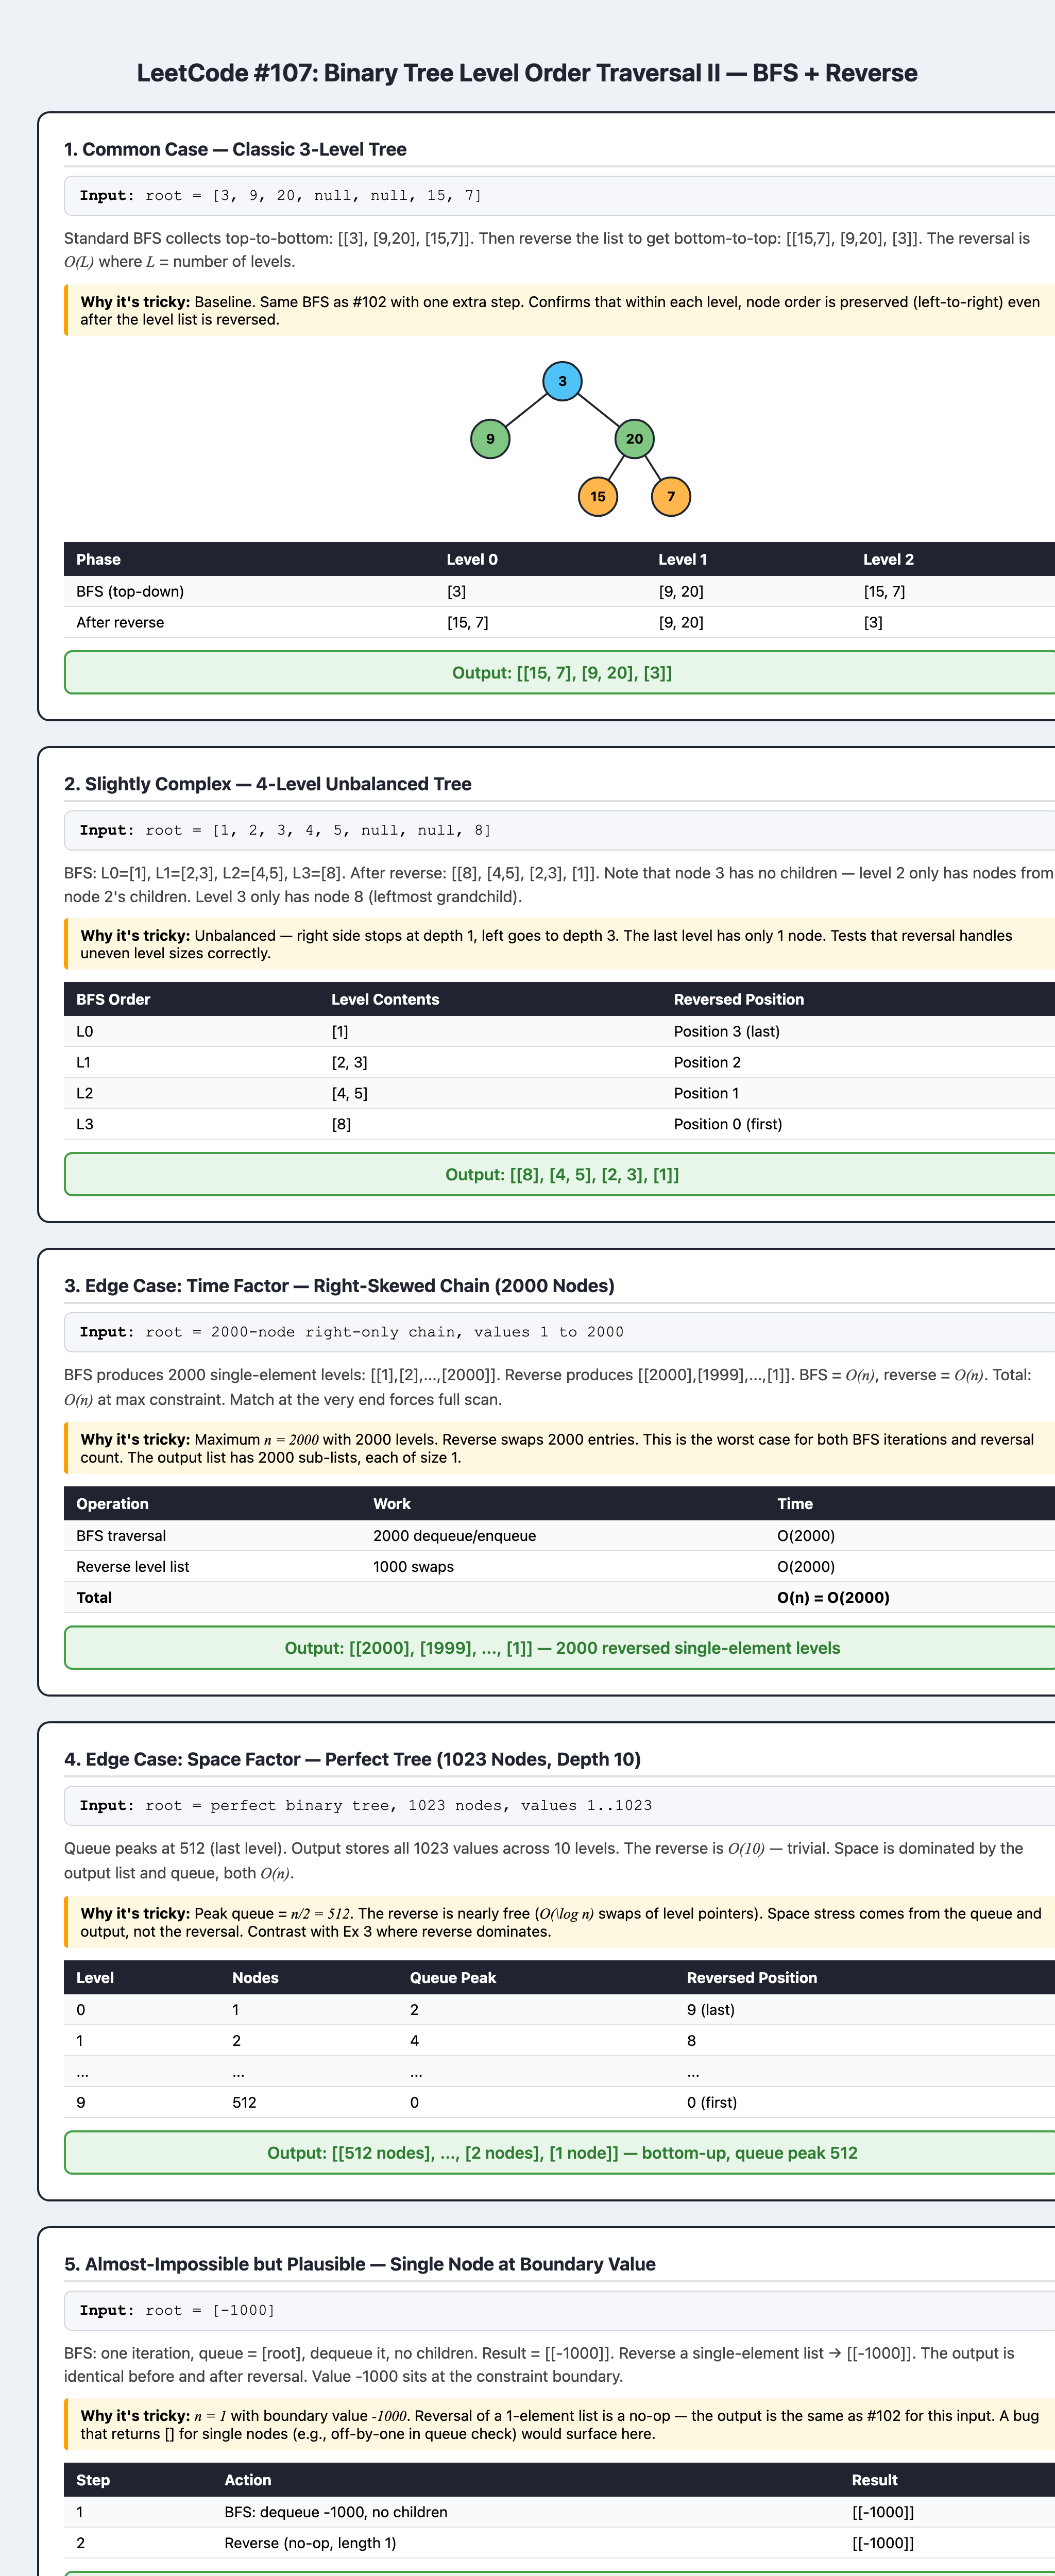